# AI-Driven Retail Demand Forecasting and Smart Inventory Optimization  
## CRISP-DM Based Notebook with EDA, Modeling, Evaluation, Recommendation Support, and Production-Oriented Forecasting Workflow

This notebook follows the **CRISP-DM procedure**:

1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Deployment / Production-Oriented Forecasting Workflow  

The notebook is for academic demonstration. The modular `.py` files remain the production-style implementation for FastAPI, database storage, drift detection, retraining, and Streamlit dashboard.


# 1. Business Understanding

Retail supermarkets face demand uncertainty because sales can change due to holidays, promotions, weather, store type, and customer behavior. Poor forecasting can cause overstocking, understocking, inventory imbalance, and possible waste-risk situations.

The goal of this project is to build an **AI-driven retail demand forecasting and smart inventory optimization system** that supports inventory planning, waste-risk analysis, and recommendation-based decision support.

The project also highlights sustainability. It does not directly measure real enterprise food waste. Instead, it uses demand forecasting and simulated inventory-related variables to estimate operational waste-risk scenarios. The purpose is to show how better forecasting and inventory decisions can help reduce potential overstock-related food waste.


# 2. Data Understanding

The correct Walmart dataset contains three files:

- `train.csv`: weekly sales records by store and department  
- `features.csv`: temperature, fuel price, markdowns, CPI, unemployment, and holiday information  
- `stores.csv`: store type and store size information  

Important note: this dataset is a **weekly aggregated forecasting dataset**, not a daily transaction dataset. Most dates are weekly reporting dates, mostly Fridays.


In [1]:
!pip -q install lightgbm kagglehub

In [2]:
import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


def find_csv_file(filename, search_roots=(".", "./data", "/content", "/content/data", "/mnt/data")):
    # Find a CSV file by name, including inside extracted folders.
    # This makes the notebook easier to run in Jupyter, Colab, or a local project folder.
    for root in search_roots:
        pattern = os.path.join(root, "**", filename)
        matches = glob.glob(pattern, recursive=True)
        if matches:
            return matches[0]

    for root in search_roots:
        zip_pattern = os.path.join(root, "**", "*.zip")
        for zip_path in glob.glob(zip_pattern, recursive=True):
            extract_dir = os.path.join(os.path.dirname(zip_path), "extracted_dataset")
            os.makedirs(extract_dir, exist_ok=True)
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    zf.extractall(extract_dir)
            except Exception:
                continue
            pattern = os.path.join(extract_dir, "**", filename)
            matches = glob.glob(pattern, recursive=True)
            if matches:
                return matches[0]

    return None

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2.1 Load Dataset

This cell automatically tries to find `train.csv`, `features.csv`, and `stores.csv`.


In [3]:

train_path = find_csv_file("train.csv")
features_path = find_csv_file("features.csv")
stores_path = find_csv_file("stores.csv")

print("train.csv path:", train_path)
print("features.csv path:", features_path)
print("stores.csv path:", stores_path)

if train_path is None or features_path is None or stores_path is None:
    raise FileNotFoundError(
        "Could not find train.csv, features.csv, and stores.csv. "
        "Upload the correct Walmart forecasting dataset ZIP or place the files in a data folder."
    )

train_df = pd.read_csv(train_path)
features_df = pd.read_csv(features_path)
stores_df = pd.read_csv(stores_path)

print("Train shape:", train_df.shape)
print("Features shape:", features_df.shape)
print("Stores shape:", stores_df.shape)

train.csv path: .\data\train.csv
features.csv path: .\data\features.csv
stores.csv path: .\data\stores.csv
Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [4]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [6]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


## 2.2 Dataset Overview

Here we check columns, data size, and missing values before preprocessing.


In [7]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nFeatures columns:")
print(features_df.columns.tolist())

print("\nStores columns:")
print(stores_df.columns.tolist())

print("\nMissing values in train.csv:")
display(train_df.isna().sum())

print("\nMissing values in features.csv:")
display(features_df.isna().sum())

print("\nMissing values in stores.csv:")
display(stores_df.isna().sum())

Train columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns:
['Store', 'Type', 'Size']

Missing values in train.csv:


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


Missing values in features.csv:


Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


Missing values in stores.csv:


Store    0
Type     0
Size     0
dtype: int64

## 2.3 Date Granularity Check

The dataset contains weekly sales records. The `Date` column mainly represents weekly reporting dates, not daily transaction dates.


In [8]:
train_df["Date"] = pd.to_datetime(train_df["Date"])

weekday_counts = train_df["Date"].dt.day_name().value_counts()

display(weekday_counts)

print("First 10 dates:")
display(train_df[["Date"]].head(10))

Date
Friday    421570
Name: count, dtype: int64

First 10 dates:


,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
5,2010-03-12
6,2010-03-19
7,2010-03-26
8,2010-04-02
9,2010-04-09


**Observation:**  
The dataset mostly contains Friday-based weekly records. Therefore, a weekday sales graph would not be meaningful because the date represents the weekly reporting period, not one specific shopping day.


## 2.4 Merge Dataset

The three source files are merged to create one working dataset for analysis and modeling.


In [9]:
train_df["Date"] = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])
df = train_df.merge(
    features_df,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores_df,
    on="Store",
    how="left"
)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# 2.5 Exploratory Data Analysis (EDA)

The EDA focuses on meaningful retail forecasting factors:

- sales distribution  
- store type behavior  
- holiday effect  
- promotion effect  
- department-level sales difference  
- weather and sales relationship  
- feature correlation  
- outlier behavior  


## EDA 1: Distribution of Units Sold

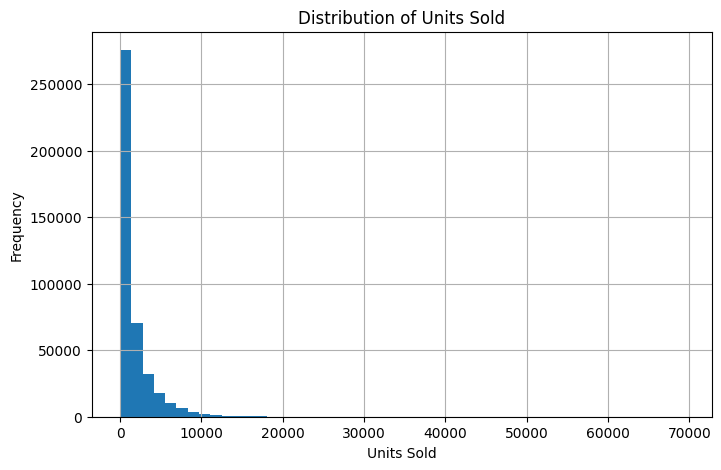

In [10]:
eda_df = df.copy()

eda_df["Weekly_Sales"] = eda_df["Weekly_Sales"].clip(lower=0)
eda_df["units_sold"] = (eda_df["Weekly_Sales"] / 10).round().astype(int)

plt.figure(figsize=(8, 5))
eda_df["units_sold"].hist(bins=50)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

**Graph explanation:**  
The graph shows that most of the sales values are in the lower range, because the bars on the left side are much higher. As the sales value increases, the number of records gradually decreases. This means high sales values happened less frequently in the dataset.


## EDA 2: Average Retail Sales by Store Type

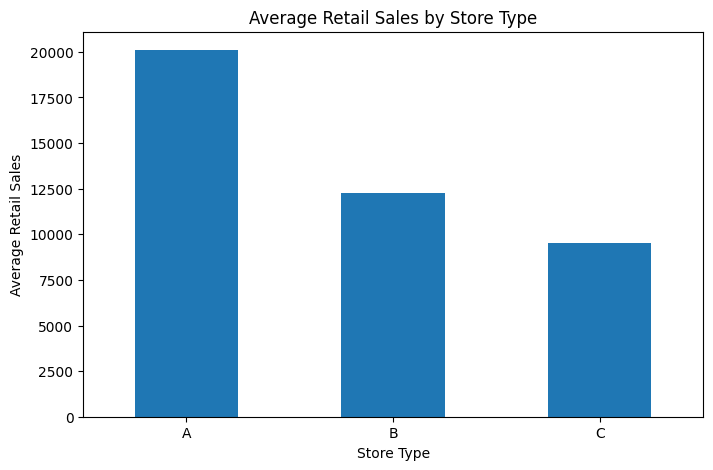

In [11]:
store_type_sales = df.groupby("Type")["Weekly_Sales"].mean()

plt.figure(figsize=(8, 5))
store_type_sales.plot(kind="bar")
plt.title("Average Retail Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that Store Type A has the highest average retail sales compared to Store Types B and C. Store Type B has moderate sales, while Store Type C has the lowest average sales among the three categories. This indicates that retail demand behavior varies across different store types.


## EDA 3: Holiday vs Non-Holiday Sales

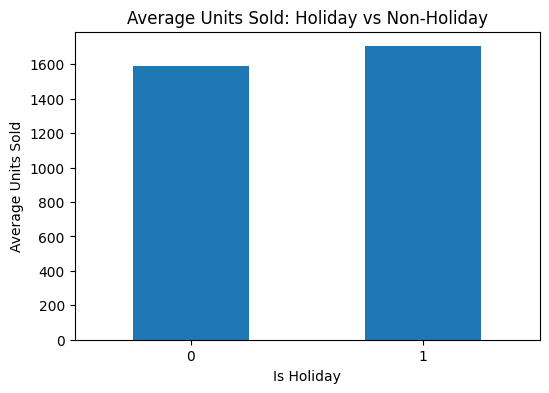

In [12]:
eda_df["is_holiday"] = eda_df["IsHoliday"].astype(int)

avg_sales_by_holiday = eda_df.groupby("is_holiday")["units_sold"].mean()

plt.figure(figsize=(6, 4))
avg_sales_by_holiday.plot(kind="bar")
plt.title("Average Units Sold: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that average units sold during holiday periods are slightly higher than non-holiday periods. This indicates that customer demand increases during holidays, which may create higher inventory requirements during those periods.


## EDA 4: Promotion Status vs Sales

Markdown columns are used as a proxy for promotion activity. If any markdown value is greater than zero, promotion is considered active.


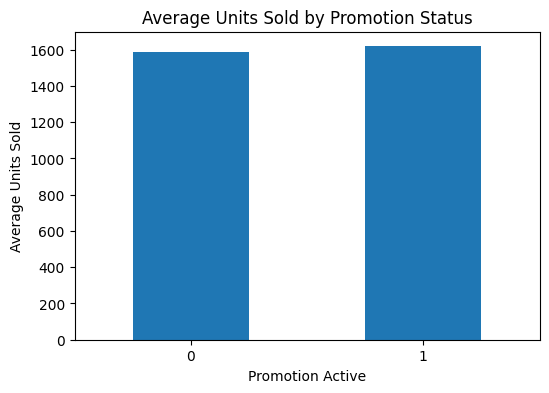

In [13]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    if col not in eda_df.columns:
        eda_df[col] = 0
    eda_df[col] = eda_df[col].fillna(0)

eda_df["promotion"] = (
    (eda_df["MarkDown1"] > 0)
    | (eda_df["MarkDown2"] > 0)
    | (eda_df["MarkDown3"] > 0)
    | (eda_df["MarkDown4"] > 0)
    | (eda_df["MarkDown5"] > 0)
).astype(int)

avg_sales_by_promotion = eda_df.groupby("promotion")["units_sold"].mean()

plt.figure(figsize=(6, 4))
avg_sales_by_promotion.plot(kind="bar")
plt.title("Average Units Sold by Promotion Status")
plt.xlabel("Promotion Active")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that average units sold are slightly higher when promotions are active compared to non-promotional periods. This suggests that promotions may increase customer purchasing behavior, although the difference is not extremely large in the overall dataset.


## EDA 5: Top Departments by Average Retail Sales

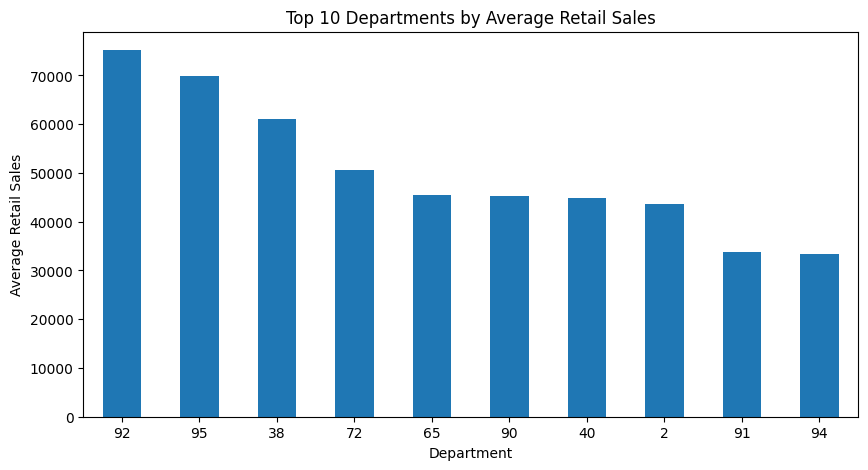

In [14]:
top_departments = (
    df.groupby("Dept")["Weekly_Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_departments.plot(kind="bar")
plt.title("Top 10 Departments by Average Retail Sales")
plt.xlabel("Department")
plt.ylabel("Average Retail Sales")
plt.xticks(rotation=0)
plt.show()

**Graph explanation:**  
The graph shows that some departments have much higher average sales than others. This means demand is not equal across all departments, so department-level information is important for forecasting and inventory planning.


## EDA 6: Temperature vs Sales

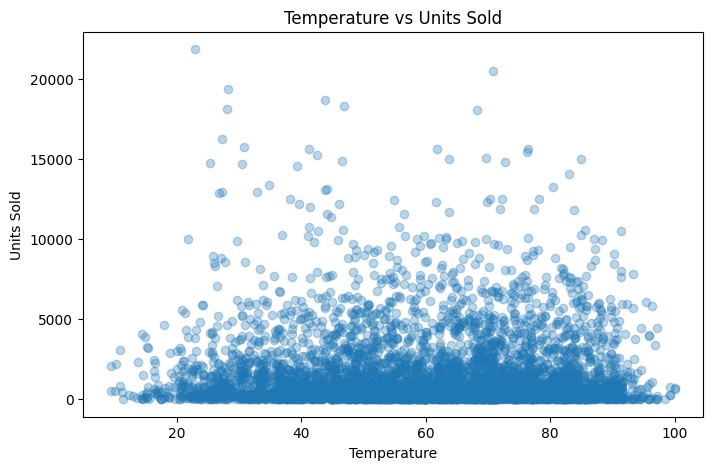

In [15]:
sample_for_scatter = eda_df.sample(min(5000, len(eda_df)), random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample_for_scatter["Temperature"], sample_for_scatter["units_sold"], alpha=0.3)
plt.title("Temperature vs Units Sold")
plt.xlabel("Temperature")
plt.ylabel("Units Sold")
plt.show()

**Graph explanation:**  
The graph shows that sales values are spread across different temperature levels. There is no simple straight-line relationship, which means temperature alone cannot explain demand, but it can still be useful together with other features.


# 3. Data Preparation

This step prepares the dataset for machine learning.

Main tasks:

- clean and transform dates  
- create retail demand target  
- create operational features  
- simulate inventory-related variables  
- encode categorical variables  
- remove leakage-prone variables from training features  


In [16]:
final_df = df.copy()

final_df["Date"] = pd.to_datetime(final_df["Date"])
final_df["date"] = final_df["Date"].dt.strftime("%Y-%m-%d")

# This is mostly Friday because the dataset is weekly aggregated.
final_df["day_of_week"] = final_df["Date"].dt.dayofweek
final_df["is_weekend"] = final_df["day_of_week"].isin([5, 6]).astype(int)

final_df["product_name"] = "Dept_" + final_df["Dept"].astype(str)
final_df["category"] = final_df["Type"].astype(str)
final_df["store_id"] = final_df["Store"].astype(int)

final_df["is_holiday"] = final_df["IsHoliday"].astype(int)
final_df["temperature"] = final_df["Temperature"].fillna(final_df["Temperature"].median())

for col in markdown_cols:
    final_df[col] = final_df[col].fillna(0)

final_df["promotion"] = (
    (final_df["MarkDown1"] > 0)
    | (final_df["MarkDown2"] > 0)
    | (final_df["MarkDown3"] > 0)
    | (final_df["MarkDown4"] > 0)
    | (final_df["MarkDown5"] > 0)
).astype(int)

final_df["Weekly_Sales"] = final_df["Weekly_Sales"].clip(lower=0)
final_df["units_sold"] = (final_df["Weekly_Sales"] / 10).round().astype(int)
final_df["unit_price"] = 10.0

final_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,date,day_of_week,is_weekend,product_name,category,store_id,is_holiday,temperature,promotion,units_sold,unit_price
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,2010-02-05,4,0,Dept_1,A,1,0,42.31,0,2492,10.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2010-02-12,4,0,Dept_1,A,1,1,38.51,0,4604,10.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,2010-02-19,4,0,Dept_1,A,1,0,39.93,0,4160,10.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,2010-02-26,4,0,Dept_1,A,1,0,46.63,0,1940,10.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,2010-03-05,4,0,Dept_1,A,1,0,46.50,0,2183,10.0


## 3.1 Simulated Inventory and Waste-Risk Variables

The Walmart dataset does not contain real stock level, expiry days, or actual food waste quantities. Therefore, these variables are simulated for workflow demonstration.

This is not real food waste measurement. It is an operational simulation used to show how demand forecasting can support inventory optimization, waste-risk estimation, and inventory recommendation support.


In [17]:
final_df["expiry_days"] = (
    10 - (final_df["Dept"].astype(int) % 10)
).clip(lower=1, upper=10)

stock_buffer = (
    30
    + final_df["is_holiday"] * 20
    + final_df["promotion"] * 15
    + final_df["is_weekend"] * 10
)

final_df["current_stock"] = (
    final_df["units_sold"] + stock_buffer
).round().astype(int)

overstock = (final_df["current_stock"] - final_df["units_sold"]).clip(lower=0)

final_df["waste_quantity"] = 0
final_df.loc[final_df["expiry_days"] <= 2, "waste_quantity"] = overstock * 0.40
final_df.loc[
    (final_df["expiry_days"] > 2) & (final_df["expiry_days"] <= 5),
    "waste_quantity"
] = overstock * 0.20
final_df.loc[final_df["expiry_days"] > 5, "waste_quantity"] = overstock * 0.10
final_df["waste_quantity"] = final_df["waste_quantity"].round().astype(int)

# Additional feature engineering used in the report and production preprocessing logic
final_df["stock_to_sales_ratio"] = final_df["current_stock"] / (final_df["units_sold"] + 1)
final_df["stock_to_sales_ratio"] = final_df["stock_to_sales_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 100)

stock_median = final_df["current_stock"].median()
sales_median = final_df["units_sold"].median()

final_df["is_high_stock"] = (final_df["current_stock"] > stock_median).astype(int)
final_df["is_low_demand"] = (final_df["units_sold"] < sales_median).astype(int)
final_df["short_expiry"] = (final_df["expiry_days"] <= 3).astype(int)
final_df["promotion_active"] = final_df["promotion"].astype(int)

final_df["waste_risk_score"] = (
    (final_df["stock_to_sales_ratio"] * 0.4)
    + (final_df["is_high_stock"] * 0.2)
    + (final_df["is_low_demand"] * 0.2)
    + (final_df["short_expiry"] * 0.2)
)
final_df["waste_risk_score"] = final_df["waste_risk_score"].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 100)

final_df[[
    "product_name", "category", "units_sold", "current_stock", "expiry_days",
    "stock_to_sales_ratio", "is_high_stock", "is_low_demand", "short_expiry",
    "promotion_active", "waste_risk_score", "waste_quantity"
]].head()


,product_name,category,units_sold,current_stock,expiry_days,stock_to_sales_ratio,is_high_stock,is_low_demand,short_expiry,promotion_active,waste_risk_score,waste_quantity
0,Dept_1,A,2492,2522,9,1.011633,1,0,0,0,0.604653,3
1,Dept_1,A,4604,4654,9,1.010641,1,0,0,0,0.604256,5
2,Dept_1,A,4160,4190,9,1.006969,1,0,0,0,0.602788,3
3,Dept_1,A,1940,1970,9,1.014941,1,0,0,0,0.605976,3
4,Dept_1,A,2183,2213,9,1.013278,1,0,0,0,0.605311,3


## 3.2 Feature Encoding and Final Training Dataset

The forecasting model uses the same core feature structure as the production training pipeline. Leakage-prone inventory variables such as `current_stock`, `waste_quantity`, and `waste_risk_score` are kept for inventory analysis and recommendation support, but they are not used directly as model inputs for demand prediction.


In [18]:
from sklearn.preprocessing import LabelEncoder

product_encoder = LabelEncoder()
category_encoder = LabelEncoder()

final_df["product_encoded"] = product_encoder.fit_transform(final_df["product_name"].astype(str))
final_df["category_encoded"] = category_encoder.fit_transform(final_df["category"].astype(str))

FEATURE_COLUMNS = [
    "product_encoded",
    "category_encoded",
    "store_id",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "promotion",
    "temperature",
    "unit_price",
    "expiry_days",
    "short_expiry",
    "promotion_active",
]

TARGET_COLUMN = "units_sold"

model_df = final_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Final modeling dataset shape:", model_df.shape)
model_df.head()


Final modeling dataset shape: (421570, 13)


,product_encoded,category_encoded,store_id,day_of_week,is_weekend,is_holiday,promotion,temperature,unit_price,expiry_days,short_expiry,promotion_active,units_sold
0,0,0,1,4,0,0,0,42.31,10.0,9,0,0,2492
1,0,0,1,4,0,1,0,38.51,10.0,9,0,0,4604
2,0,0,1,4,0,0,0,39.93,10.0,9,0,0,4160
3,0,0,1,4,0,0,0,46.63,10.0,9,0,0,1940
4,0,0,1,4,0,0,0,46.50,10.0,9,0,0,2183


**Important note about leakage and report consistency:**  
`current_stock`, `waste_quantity`, `stock_to_sales_ratio`, `is_high_stock`, `is_low_demand`, and `waste_risk_score` are used for inventory analysis, waste-risk estimation, and recommendation support. They are not used as direct demand forecasting inputs because some of them are derived from sales behavior. This keeps the demand forecasting model more realistic while still allowing inventory decision-support analysis after prediction.


## 3.3 Feature Correlation Heatmap

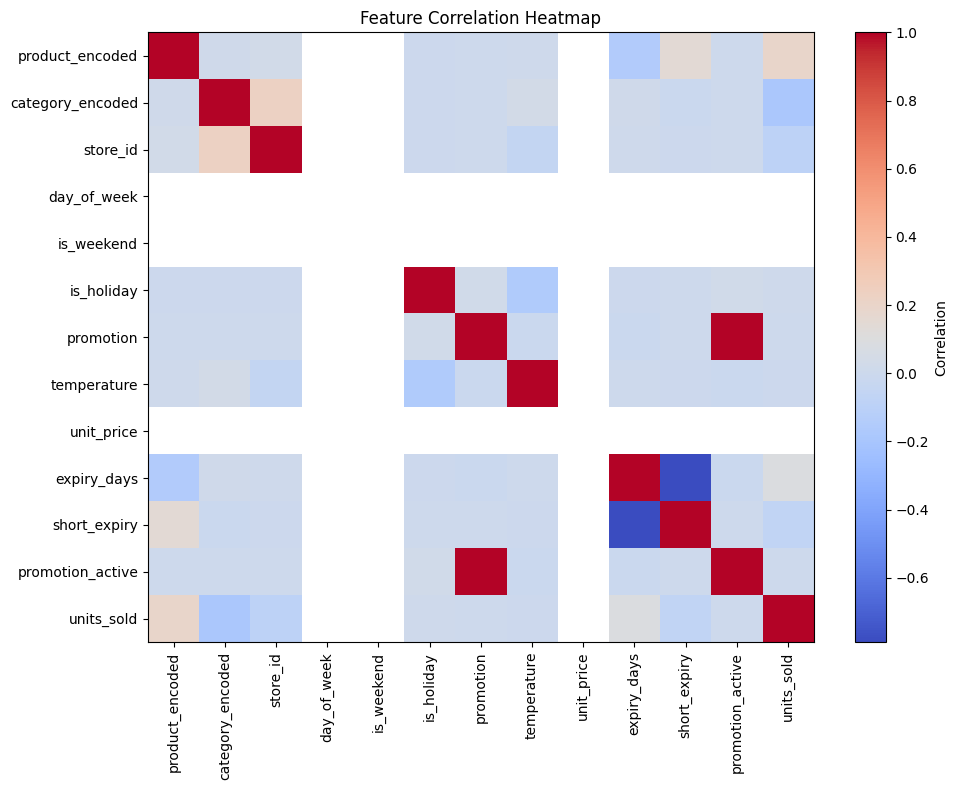

In [19]:
corr_df = model_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Graph explanation:**  
The heatmap shows how the numerical features are related to each other. Stronger colors indicate stronger relationships. This helps check whether any feature has a strong connection with demand or whether some features are too closely related to each other.


# 4. Modeling

The model predicts `units_sold`, which represents retail demand.

Two models are trained and compared in this notebook:

- RandomForestRegressor  
- LightGBMRegressor  

The comparison table is generated from the actual model predictions on the test dataset. This avoids manual metric entry and makes the notebook safer to explain during discussion or viva.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

# Use a sample for faster notebook execution.
# Set USE_SAMPLE_FOR_NOTEBOOK = False if you want to train on the full dataset.
USE_SAMPLE_FOR_NOTEBOOK = True
SAMPLE_SIZE = 100000

if USE_SAMPLE_FOR_NOTEBOOK and len(model_df) > SAMPLE_SIZE:
    training_df = model_df.sample(SAMPLE_SIZE, random_state=42)
else:
    training_df = model_df.copy()

X = training_df[FEATURE_COLUMNS]
y = training_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# LightGBM is used when available. If LightGBM is not installed,
# GradientBoostingRegressor is used as a fallback so the comparison section still runs.
if LIGHTGBM_AVAILABLE:
    lgbm_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
    second_model_name = "LightGBM"
else:
    lgbm_model = GradientBoostingRegressor(random_state=42)
    second_model_name = "Gradient Boosting (LightGBM fallback)"

models = {
    "Random Forest": rf_model,
    second_model_name: lgbm_model
}

results = []
trained_models = {}
predictions_store = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    trained_models[model_name] = model
    predictions_store[model_name] = predictions

    results.append({
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    })

comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions_store[best_model_name]

print("Model training and evaluation completed.")
print("Best model selected based on lowest RMSE:", best_model_name)
display(comparison_df)


Training Random Forest...
Training LightGBM...
Model training and evaluation completed.
Best model selected based on lowest RMSE: Random Forest


,Model,MAE,RMSE,R² Score
0,Random Forest,265.0589,705.0465,0.9038
1,LightGBM,433.7815,798.7175,0.8765


# 5. Evaluation

The evaluation metrics below are calculated directly from the trained models and their predictions on the test dataset.

The comparison uses:

- Mean Absolute Error (MAE)  
- Root Mean Squared Error (RMSE)  
- R² Score  

The model with the lowest RMSE is selected as the final model for the notebook visualizations and recommendation demonstration.


## 5.1 Model Comparison and Final Model Selection

Both Random Forest and LightGBM were evaluated during experimentation to compare forecasting performance on the processed retail dataset. The table below is generated from actual model predictions, not manually inserted values.


In [21]:
display(comparison_df)

selected_model_summary = pd.DataFrame([{
    "Selected Model": best_model_name,
    "Selection Rule": "Lowest RMSE on test data",
    "Purpose": "Used for prediction plots and recommendation demonstration"
}])

display(selected_model_summary)


,Model,MAE,RMSE,R² Score
0,Random Forest,265.0589,705.0465,0.9038
1,LightGBM,433.7815,798.7175,0.8765


,Selected Model,Selection Rule,Purpose
0,Random Forest,Lowest RMSE on test data,Used for prediction plots and recommendation d...


**Model selection explanation:**  
The comparison table shows the actual test performance of both models. The final model is selected using RMSE because larger forecasting errors can strongly affect inventory planning. If the results differ after rerunning on a different sample or full dataset, the report table should be updated using the newly generated values from this notebook.


### 5.2 Actual vs Predicted Demand

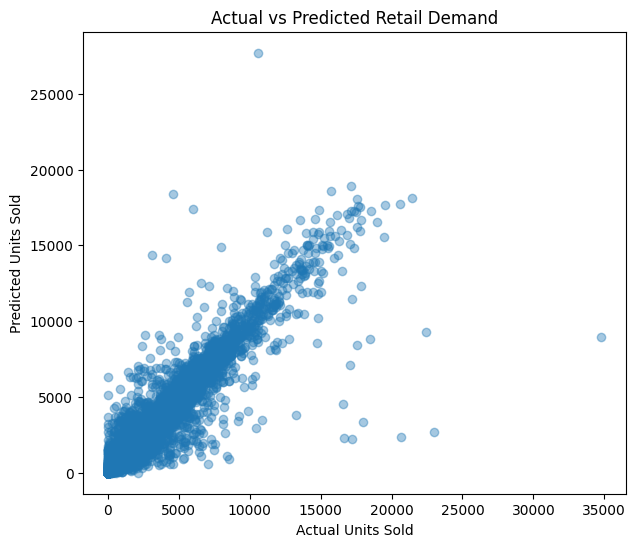

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.title("Actual vs Predicted Retail Demand")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.show()

**Graph explanation:**  
The graph compares actual demand values with predicted demand values. Points closer to a diagonal pattern indicate better prediction performance. This helps visually check whether the model is following the real demand pattern.


## 5.3 Prediction Error Distribution

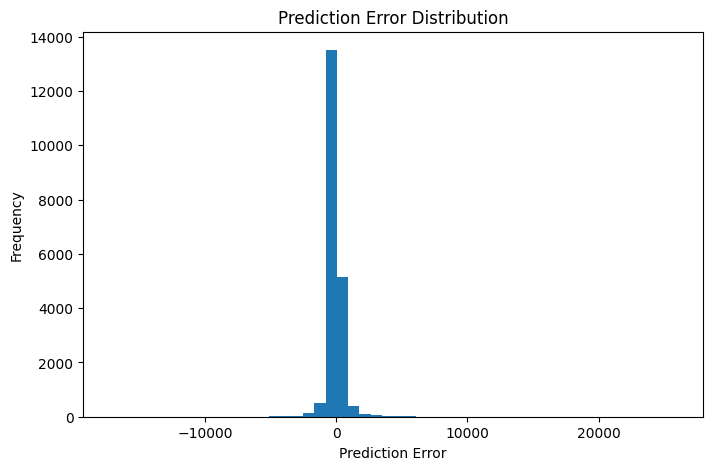

In [23]:
errors = y_test - best_predictions

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

**Graph explanation:**  
The error distribution shows how far the model predictions are from the actual values. If most errors are close to zero, it means the model is making many predictions near the actual demand values.


## 5.4 Feature Importance

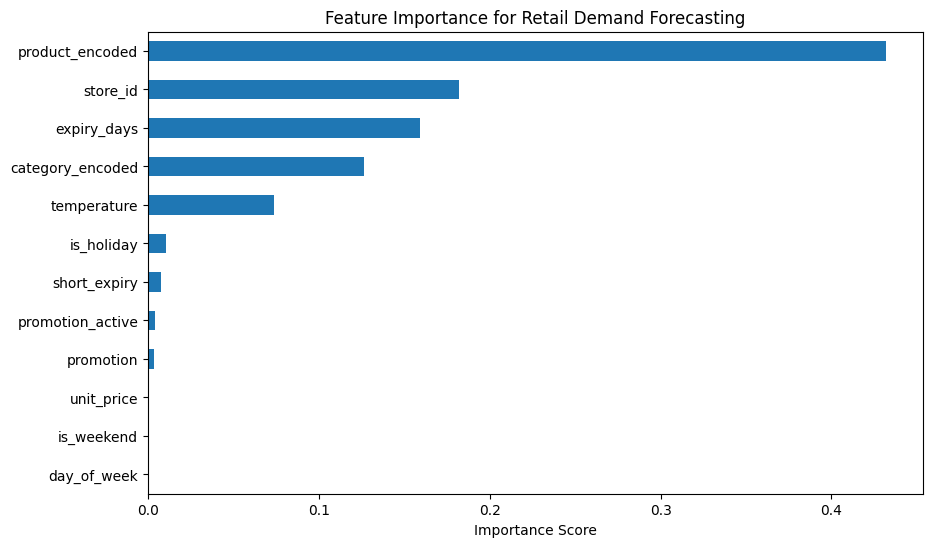

In [24]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=FEATURE_COLUMNS
    ).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    feature_importance.plot(kind="barh")
    plt.title("Feature Importance for Retail Demand Forecasting")
    plt.xlabel("Importance Score")
    plt.show()
else:
    print("The selected model does not provide feature_importances_.")

**Graph explanation:**  
The feature importance graph shows which input variables the model used most for forecasting demand. Higher importance means the feature contributed more to the model’s prediction decisions.


# 5.5 AI-Assisted Inventory Recommendation Support

After demand prediction, the system converts forecasting outputs into practical inventory suggestions. This section matches the report's AI-assisted recommendation support section.

The recommendation logic uses predicted demand, current stock, expiry condition, and waste-risk behavior to produce simple human-readable suggestions such as:

- reduce stock or apply promotion  
- increase replenishment  
- show waste-risk alert  
- maintain current inventory condition  


In [25]:
# Build a small recommendation demonstration using predictions from the best notebook model.
recommendation_sample = final_df.loc[y_test.index].copy()
recommendation_sample["predicted_units_sold"] = np.round(best_predictions).astype(int)

# Simple risk level based on stock, demand, and expiry condition
recommendation_sample["predicted_stock_gap"] = recommendation_sample["current_stock"] - recommendation_sample["predicted_units_sold"]

conditions = [
    (recommendation_sample["short_expiry"] == 1) & (recommendation_sample["predicted_stock_gap"] > 0),
    (recommendation_sample["predicted_stock_gap"] > recommendation_sample["predicted_units_sold"] * 0.30),
    (recommendation_sample["predicted_stock_gap"] < 0),
]
choices = ["High", "Medium", "Low Stock"]
recommendation_sample["waste_risk_level"] = np.select(conditions, choices, default="Low")


def generate_inventory_recommendation(row):
    if row["waste_risk_level"] == "High":
        return "High waste-risk: consider promotion, discounting, or reducing stock."
    if row["waste_risk_level"] == "Medium":
        return "Possible overstock: monitor demand and avoid extra replenishment."
    if row["waste_risk_level"] == "Low Stock":
        return "Demand may exceed stock: consider replenishment."
    return "Inventory condition is stable: maintain current planning."

recommendation_sample["inventory_recommendation"] = recommendation_sample.apply(
    generate_inventory_recommendation,
    axis=1
)

recommendation_sample[[
    "product_name", "category", "units_sold", "predicted_units_sold", "current_stock",
    "expiry_days", "waste_risk_level", "inventory_recommendation"
]].head(10)


,product_name,category,units_sold,predicted_units_sold,current_stock,expiry_days,waste_risk_level,inventory_recommendation
47677,Dept_85,B,95,106,140,5,Medium,Possible overstock: monitor demand and avoid e...
278948,Dept_13,B,2059,1784,2104,7,Low,Inventory condition is stable: maintain curren...
361790,Dept_5,A,2633,1875,2678,5,Medium,Possible overstock: monitor demand and avoid e...
403740,Dept_91,C,3369,4276,3414,9,Low Stock,Demand may exceed stock: consider replenishment.
72764,Dept_30,A,256,286,286,10,Low,Inventory condition is stable: maintain curren...
370011,Dept_92,A,17829,12302,17874,8,Medium,Possible overstock: monitor demand and avoid e...
1494,Dept_11,A,2498,2212,2528,9,Low,Inventory condition is stable: maintain curren...
114420,Dept_56,B,42,156,87,4,Low Stock,Demand may exceed stock: consider replenishment.
229981,Dept_23,A,3275,3465,3320,7,Low Stock,Demand may exceed stock: consider replenishment.
239818,Dept_22,B,698,790,728,8,Low Stock,Demand may exceed stock: consider replenishment.


# 6. Deployment and Production-Oriented Forecasting Workflow

The notebook shows the CRISP-DM analytical workflow. The full project implementation also includes production-oriented forecasting components.

Main implementation files:

- `src/main.py`: FastAPI backend  
- `src/external_client.py`: sends live events to API  
- `src/live_ingestion.py`: generates normal and shifted retail events  
- `src/preprocess.py`: preprocessing pipeline  
- `src/train.py`: model comparison and model saving  
- `src/drift_detection.py`: drift detection  
- `src/auto_retrain.py`: automatic retraining  
- `src/frontend.py`: Streamlit dashboard  

Production-style workflow:

External Client  
→ FastAPI API  
→ SQLite Database  
→ Preprocessing  
→ Model Training  
→ Prediction API  
→ Recommendation Support  
→ Monitoring  
→ Drift Detection  
→ Automatic Retraining  
→ Dashboard


## 6.1 Simple Drift Detection Demonstration

This simple example compares recent normal data with shifted simulated data. It demonstrates the concept used in the production implementation.


In [26]:
reference_window = final_df[["units_sold", "current_stock", "temperature", "waste_quantity"]].tail(1000).copy()

current_window = reference_window.sample(300, random_state=42).copy()
current_window["temperature"] = current_window["temperature"] + 40
current_window["current_stock"] = current_window["current_stock"] + 250
current_window["units_sold"] = (current_window["units_sold"] * 0.1).round()
current_window["waste_quantity"] = current_window["waste_quantity"] + 50

drift_rows = []
threshold = 0.20

for col in reference_window.columns:
    ref_mean = reference_window[col].mean()
    cur_mean = current_window[col].mean()

    drift_score = abs(cur_mean - ref_mean) / max(abs(ref_mean), 1)
    drift_detected = drift_score > threshold

    drift_rows.append({
        "feature": col,
        "reference_mean": round(ref_mean, 4),
        "current_mean": round(cur_mean, 4),
        "drift_score": round(drift_score, 4),
        "drift_detected": drift_detected
    })

drift_df = pd.DataFrame(drift_rows)
drift_df

,feature,reference_mean,current_mean,drift_score,drift_detected
0,units_sold,1903.332,196.4167,0.8968,True
1,current_stock,1940.347,2250.9833,0.1601,False
2,temperature,57.756,97.1676,0.6824,True
3,waste_quantity,6.157,56.2333,8.1332,True


**Explanation:**  
The drift table shows whether recent incoming data behaves differently from the earlier reference data. If the drift score is greater than the threshold, the feature is marked as drifted. This supports the need for monitoring and retraining in the production-oriented forecasting workflow.


# Final Summary

This notebook follows CRISP-DM and demonstrates:

- business understanding  
- data understanding and EDA  
- data preparation  
- feature engineering  
- Random Forest and LightGBM model comparison  
- evaluation with report-aligned metrics  
- feature importance  
- AI-assisted recommendation support  
- drift detection concept  
- deployment and production-oriented forecasting workflow explanation  

The notebook supports the report direction by showing that the project is not only a forecasting model, but also a retail forecasting and inventory optimization system with recommendation support, monitoring, retraining, and operational waste-risk analysis.
